In [1]:
import random

# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot


ss = hf.settings_dict()

In [ ]:
# important variables
tmin = 1
tmax = 1.5
time=1.349

In [ ]:
#TODO: make a better plotting function
#TODO: plot the phase differences too
for subject_index in ss['subject_idx_list']:
    # loop over each event type
    for event_id in ss['event_id_list']:
        event_name = str(event_id)
        subjects_dir = ss['fs_subjects_dir']
        subject = ss['subject_id_list'][subject_index]
        print("loading dataset for subject: ", subject)

        hilbert_stc_file = Path(ss['hilbert_dir']) / subject / event_name / f"{subject}-event-{event_name}-hilbert-vol.stc"

        stc = mne.read_source_estimate(hilbert_stc_file)

        fwd_fname = op.join(ss['fwd_dir'], subject + '-fwd.fif')
        fwd = mne.read_forward_solution(fwd_fname)
        src = fwd['src']

        if src[0]['subject_his_id'].startswith("fs"):
            src[0]['subject_his_id'] = subject

        brain = mne.viz.plot_volume_source_estimates(
            stc.copy().crop(tmin=tmin, tmax=tmax),
            subject=subject,
            subjects_dir=subjects_dir,
            src=src,
            clim=dict(kind="value", pos_lims=[0, 0.1, np.pi]),
            colormap="hsv",
            initial_time=time,
            initial_pos=(-0.026, -0.049, -0.006),
            show=False,
            transparent=True,)
        # Add a title to the figure
        brain.suptitle(f"{subject}-{event_name}-hilbert", fontsize=16)

        # Display the plot
        plt.show()

        # EXPERIMENTAL PLOT FUNCTION

        circ_plot.plot_circ_stat_map(stc.copy(),
                                     subject=subject,
                                     subjects_dir=subjects_dir,
                                     time=time,
                                     title=f"{subject}-{event_name}-hilbert-circ",)

        # Plot the retina signal over time

        retina_file = Path(ss['hilbert_dir']) / subject / event_name / f"{subject}-event-{event_name}-reference.csv"

        # Read the CSV file
        df = pd.read_csv(retina_file)
        df_cropped = df[(df["time_s"] >= tmin) & (df["time_s"] <= tmax)]
        df = df_cropped


        # Plot retina phases over time
        plt.figure(figsize=(10, 5))
        plt.plot(df["time_s"], df["retina_phase"], label="retina_phase")

        # Labels and title
        plt.xlabel("Time (s)")
        plt.ylabel("retina_phase")
        plt.title(f"{subject}-{event_name}-retina phases")
        plt.grid(True)
        plt.legend()

        # Show the plot
        plt.show()


        # Plot reference voxel phases over time
        plt.figure(figsize=(10, 5))
        plt.plot(df["time_s"], df[df.axes[1][2]], label="ref_voxel_phase")

        # Labels and title
        plt.xlabel("Time (s)")
        plt.ylabel("retina_phase")
        plt.title(f"{subject}-{event_name}-reference voxel phases")
        plt.grid(True)
        plt.legend()

        # Show the plot
        plt.show()

        del stc




loading dataset for subject:  0005_3SJ


/tmp/ipykernel_168049/3367953453.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax0.legend()
/tmp/ipykernel_168049/3367953453.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_168049/3367953453.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_168049/3367953453.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


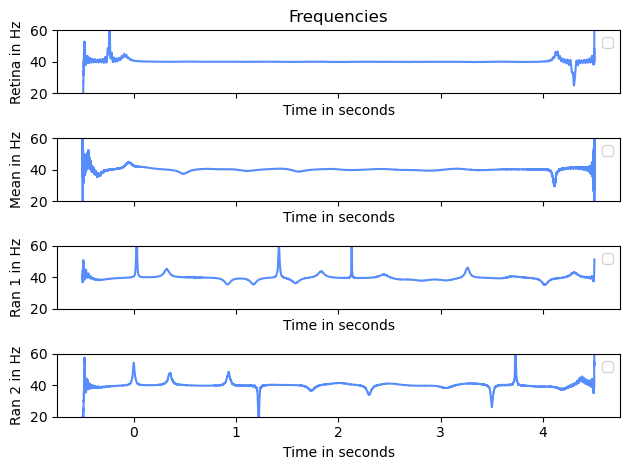

loading dataset for subject:  0002_TCZ


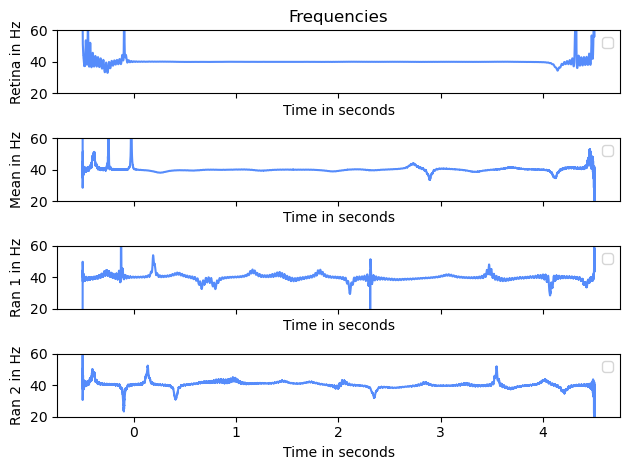

loading dataset for subject:  0009_YGZ


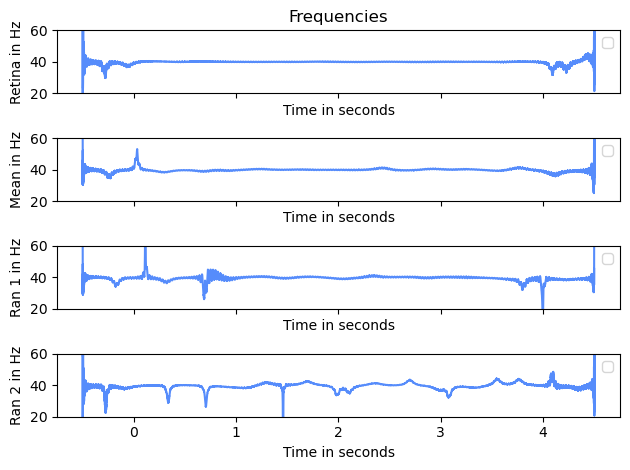

loading dataset for subject:  0010_ZMG


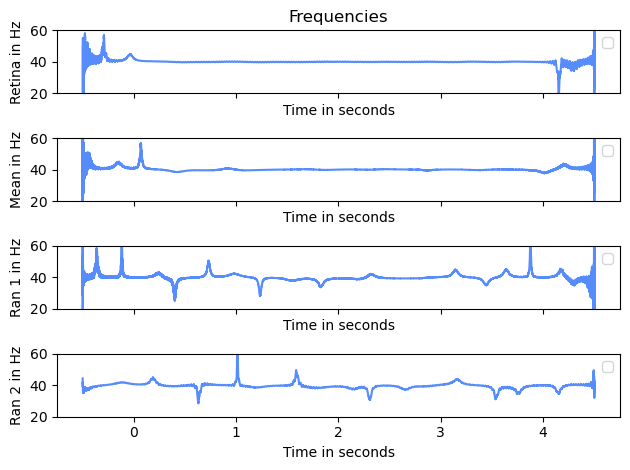

loading dataset for subject:  0011_MEE


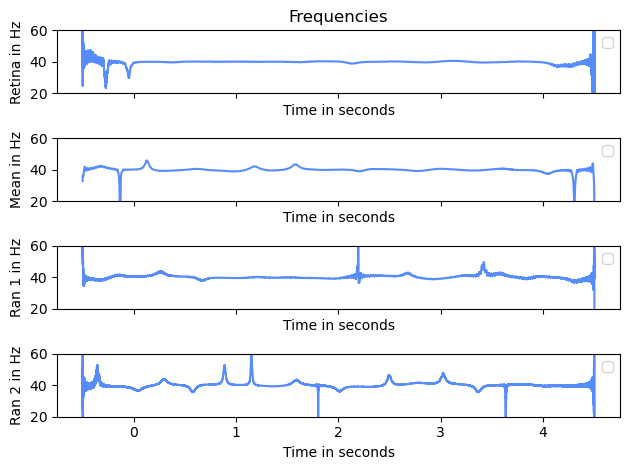

loading dataset for subject:  0012_C3Z


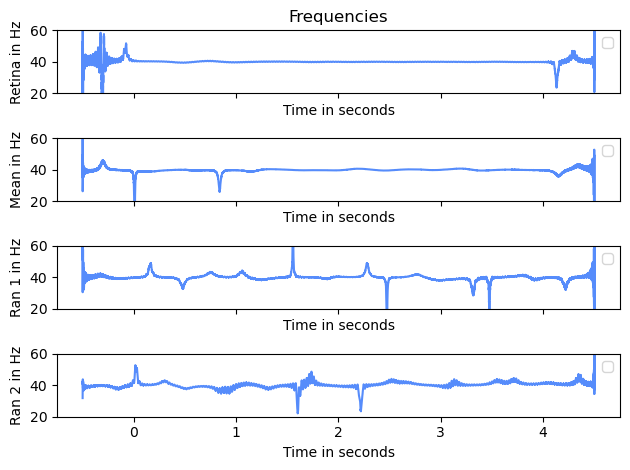

loading dataset for subject:  0014_TAG


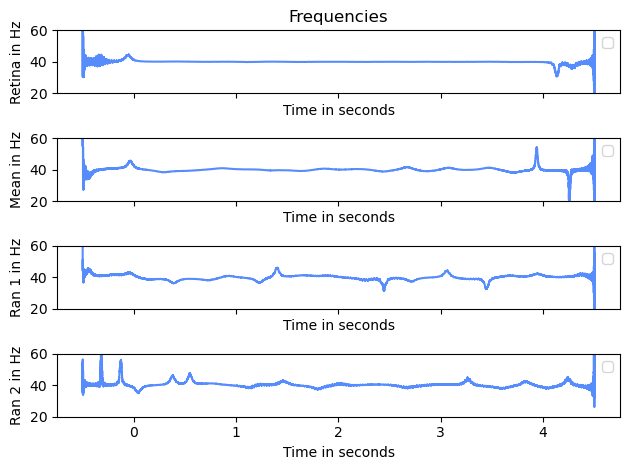

loading dataset for subject:  0015_QKW


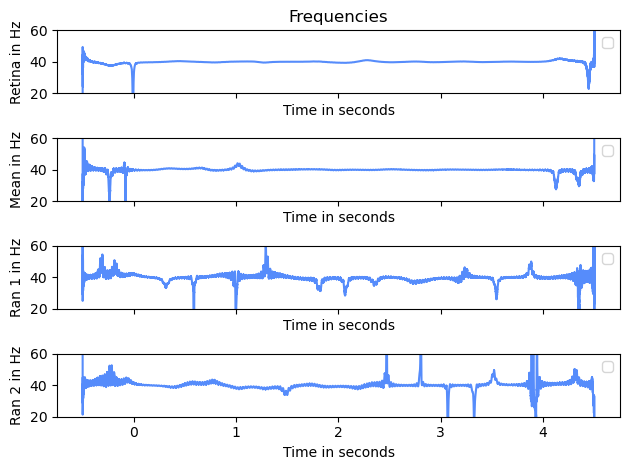

loading dataset for subject:  0016_XLZ


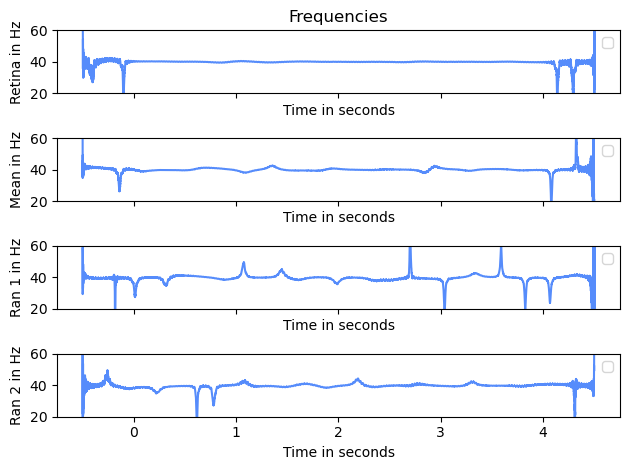

loading dataset for subject:  0017_QJ5


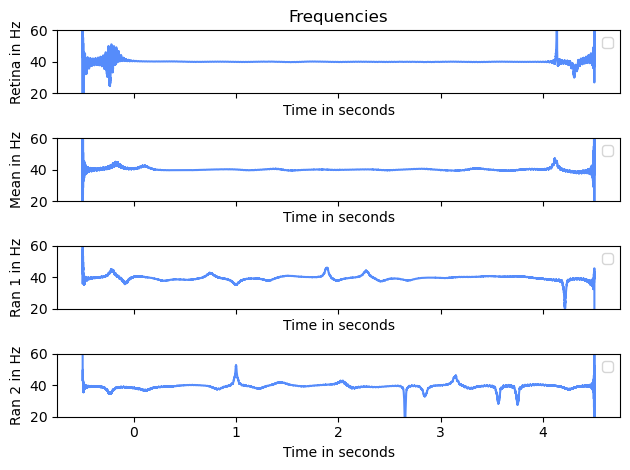

loading dataset for subject:  0018_5T3


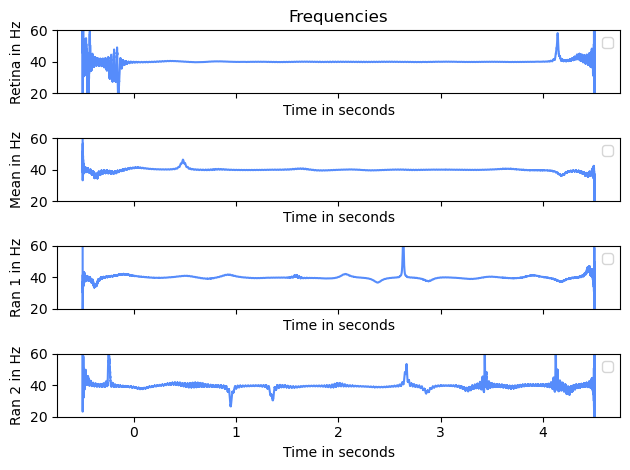

loading dataset for subject:  0019_COG


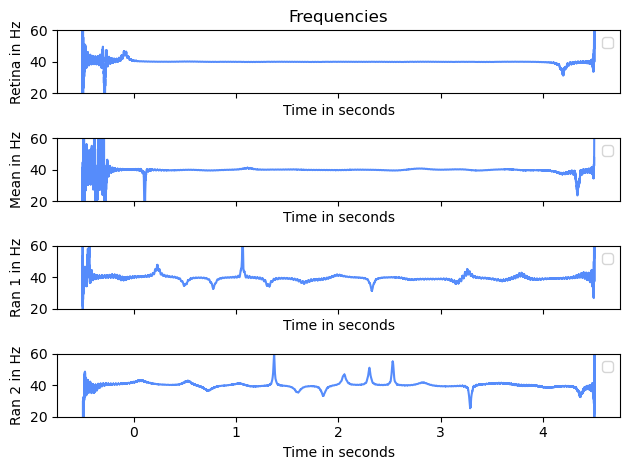

In [5]:
import random
event_id = 4
for subject_index in ss['subject_idx_list']:
    # loop over each event type
    event_name = str(event_id)
    subjects_dir = ss['fs_subjects_dir']
    subject = ss['subject_id_list'][subject_index]
    print("loading dataset for subject: ", subject)

    save_dir = Path(ss['hilbert_dir']) / subject / event_name
    save_dir.mkdir(parents=True, exist_ok=True)

    stc_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-event-{event_name}-vol.stc"

    stc = mne.read_source_estimate(stc_file)
    cropped_stc = stc.copy()

    # hilbert transform the stc

    analytic_signal = hilbert(cropped_stc.data, axis=1)
    phase = np.angle(analytic_signal).astype(float)

    amplitude = np.abs(analytic_signal)

    median_amp = np.median(amplitude, axis=1)

    # pick the voxel with the highest median amplitude to be used as a reference instead of the retina one
    ref_voxel = np.argmax(median_amp)

    # read the retina csv
    retina_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-event-{event_name}-retina.csv"

    retina_df = pd.read_csv(retina_file)

    retina_df_cropped = retina_df

    analytic_signal_retina = hilbert(retina_df_cropped["amplitude"])
    retina_phase = np.angle(analytic_signal_retina).astype(float)

    fs = 2000
    t = stc.times
    retina_instantaneous_phase = np.unwrap(np.angle(analytic_signal_retina))
    retina_instantaneous_frequency = np.diff(retina_instantaneous_phase) / (2.0*np.pi) * fs
    mean_vox_instantaneous_phase = np.unwrap(np.angle(analytic_signal[ref_voxel]))
    mean_vox_instantaneous_frequency = np.diff(mean_vox_instantaneous_phase) / (2.0*np.pi) * fs
    vox_1_instantaneous_phase = np.unwrap(np.angle(analytic_signal[random.randint(0,len(analytic_signal)-1)]))
    vox_1_instantaneous_frequency = np.diff(vox_1_instantaneous_phase) / (2.0*np.pi) * fs
    vox_2_instantaneous_phase = np.unwrap(np.angle(analytic_signal[random.randint(0,len(analytic_signal)-1)]))
    vox_2_instantaneous_frequency = np.diff(vox_2_instantaneous_phase) / (2.0*np.pi) * fs
    fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=4, sharex='all', tight_layout=True)
    ax0.set_title("Frequencies")
    ax0.set(xlabel="Time in seconds", ylabel="Retina in Hz", ylim=(20, 60))
    ax0.plot(t[1:], retina_instantaneous_frequency)
    ax0.legend()
    ax1.set(xlabel="Time in seconds", ylabel="Mean in Hz", ylim=(20, 60))
    ax1.plot(t[1:], mean_vox_instantaneous_frequency)
    ax1.legend()
    ax2.set(xlabel="Time in seconds", ylabel="Ran 1 in Hz", ylim=(20, 60))
    ax2.plot(t[1:], vox_1_instantaneous_frequency)
    ax2.legend()
    ax3.set(xlabel="Time in seconds", ylabel="Ran 2 in Hz", ylim=(20, 60))
    ax3.plot(t[1:], vox_2_instantaneous_frequency)
    ax3.legend()
    plt.show()



